# Lab 12: Employee Retention Study

This lab analyzes a simulated employee retention dataset from a mid-sized technology company. The dataset contains information on 500 employees hired over a 5-year period, tracking whether and when they left the company.


## Import Libraries


In [14]:
# Import core libraries for data manipulation and visualization
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS
from ISLP.survival import sim_time

# Import survival analysis tools from the lifelines package
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test


## Data Generation

Generate the employee retention dataset with 500 employees.


In [15]:
# Set random seed for reproducibility
rng = np.random.default_rng(42)
N = 500  # Number of employees

# Generate covariates
departments = ['Engineering', 'Sales', 'Marketing', 'HR', 'Operations']
department = rng.choice(departments, N, replace=True)
experience = rng.exponential(3, N)  # Years of prior experience
experience = np.clip(experience, 0, 15)  # Cap at 15 years
performance = rng.normal(3.5, 0.8, N)  # Performance rating
performance = np.clip(performance, 1.0, 5.0)  # Clip to 1-5 scale
salary = rng.normal(75, 20, N)  # Starting salary in thousands
salary = np.clip(salary, 40, 150)  # Reasonable salary range
remote_work = rng.choice([0, 1], N, p=[0.6, 0.4])  # 40% remote

# Create DataFrame with covariates
employee_data = pd.DataFrame({
    'department': pd.Categorical(department),
    'experience': experience,
    'performance': performance,
    'salary': salary,
    'remote_work': remote_work
})

# Create model matrix for Cox model simulation
model = MS(['department', 'experience', 'performance', 'salary', 'remote_work'],
           intercept=False)
X = model.fit_transform(employee_data)

# Define true coefficients (to simulate realistic retention patterns)
# Negative coefficients = lower hazard (better retention)
# Positive coefficients = higher hazard (worse retention)
# Coefficients will match the order of columns in X
# ModelSpec orders categorical variables alphabetically, so department order is:
# Engineering (baseline), HR, Marketing, Operations, Sales
# Then: experience, performance, salary, remote_work

# Create coefficient dictionary for clarity
coef_dict = {}
# Department coefficients (Engineering is baseline, so not included)
coef_dict['department_HR'] = -0.2  # HR has better retention than Engineering
coef_dict['department_Marketing'] = 0.1  # Marketing slightly worse
coef_dict['department_Operations'] = -0.1  # Operations slightly better
coef_dict['department_Sales'] = 0.3  # Sales has worse retention
# Continuous variables
coef_dict['experience'] = -0.02  # More experience = better retention
coef_dict['performance'] = -0.15  # Higher performance = better retention
coef_dict['salary'] = -0.01  # Higher salary = better retention
coef_dict['remote_work'] = -0.2  # Remote work = better retention

# Create coefficient array matching X column order
true_beta = np.array([coef_dict.get(col, 0.0) for col in X.columns])

# Compute linear predictor
true_linpred = X.dot(true_beta)

# Define baseline hazard function (increasing hazard over time)
# h₀(t) = 0.01 * t (hazard increases linearly with months)
hazard = lambda t: 0.01 * t

# Define cumulative hazard function
# H₀(t) = ∫h₀(s)ds = 0.01 * t² / 2
cum_hazard = lambda t: 0.01 * t**2 / 2

# Simulate employment duration (time until departure or censoring)
# Maximum employment duration: 60 months (5 years)
W = np.array([sim_time(l, cum_hazard, rng) for l in true_linpred])
employee_data['time'] = np.clip(W, 0, 60)

# Simulate censoring (70% left, 30% still employed)
employee_data['event'] = rng.choice([1, 0], N, p=[0.7, 0.3])

# Display first few rows
print("Employee Retention Dataset")
print("=" * 50)
employee_data.head(10)


Employee Retention Dataset


,department,experience,performance,salary,remote_work,time,event
0,Engineering,4.130296,4.301396,100.539617,0,19.939382,1
1,HR,6.422651,4.450180,54.974171,0,34.925516,1
2,HR,8.009661,2.683502,108.671724,1,54.876812,1
3,Marketing,0.906032,2.012132,64.380470,0,7.890572,1
4,Marketing,3.077399,3.579228,95.897456,1,17.657787,1
5,Operations,1.539910,4.244671,76.359733,1,40.567524,0
6,Engineering,5.135785,4.938076,66.757012,0,33.386044,1
7,HR,0.662143,3.913038,40.000000,1,4.337477,0
8,Sales,0.176839,3.202627,71.568710,0,15.133875,1
9,Engineering,1.082742,2.785496,43.812335,0,15.406414,0


# Part 1: Basic Kaplan-Meier Estimation

## Part 1a: Load and Summarize Dataset


In [16]:
# Dataset dimensions
print("Dataset Dimensions:")
print(f"  Rows: {employee_data.shape[0]}")
print(f"  Columns: {employee_data.shape[1]}")
print()

# Number of departures vs censored observations
print("Event Status:")
event_counts = employee_data['event'].value_counts()
print(f"  Departures (event=1): {event_counts.get(1, 0)}")
print(f"  Still Employed (event=0, censored): {event_counts.get(0, 0)}")
print(f"  Departure Rate: {event_counts.get(1, 0) / N * 100:.1f}%")
print()

# Summary statistics for continuous variables
print("Summary Statistics:")
print(employee_data[['time', 'experience', 'performance', 'salary']].describe())
print()

# Distribution of employees across departments
print("Distribution by Department:")
dept_counts = employee_data['department'].value_counts()
print(dept_counts)
print()
print("Percentage by Department:")
print(dept_counts / N * 100)


Dataset Dimensions:
  Rows: 500
  Columns: 7

Event Status:
  Departures (event=1): 361
  Still Employed (event=0, censored): 139
  Departure Rate: 72.2%

Summary Statistics:
             time  experience  performance      salary
count  500.000000  500.000000   500.000000  500.000000
mean    25.030833    3.039672     3.495352   74.073557
std     13.021307    3.057952     0.775126   19.837201
min      1.206234    0.003315     1.000000   40.000000
25%     15.294174    0.812356     2.994287   60.655139
50%     22.752788    1.991086     3.522278   74.188831
75%     33.581641    4.175330     3.998217   87.071242
max     60.000000   15.000000     5.000000  133.284893

Distribution by Department:
department
Marketing      110
HR             106
Engineering    105
Operations      92
Sales           87
Name: count, dtype: int64

Percentage by Department:
department
Marketing      22.0
HR             21.2
Engineering    21.0
Operations     18.4
Sales          17.4
Name: count, dtype: float64


## Part 1b: Fit Kaplan-Meier Estimator


In [17]:
# Fit Kaplan-Meier estimator for overall employee retention
km = KaplanMeierFitter()
km_fit = km.fit(employee_data['time'], employee_data['event'])
print("Kaplan-Meier Estimator Fitted Successfully")
# Get number of observations and events directly from input data
total_observations = len(employee_data)
total_events = employee_data['event'].sum()
print(f"Number of observations: {total_observations}")
print(f"Number of events: {total_events}")


Kaplan-Meier Estimator Fitted Successfully
Number of observations: 500
Number of events: 361


## Part 1c: Create Survival Plot with Confidence Intervals


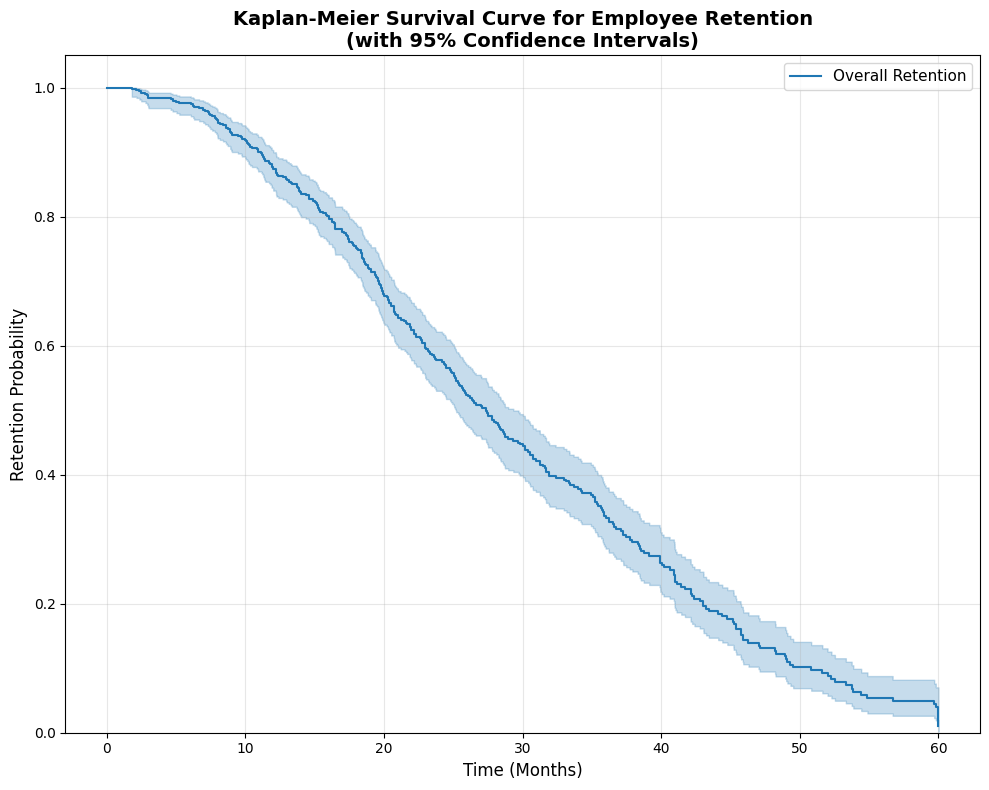

In [18]:
# Create survival plot with shaded confidence intervals
fig, ax = subplots(figsize=(10, 8))
km_fit.plot(ax=ax, label='Overall Retention', 
            ci_show=True,  # Show confidence intervals
            at_risk_counts=False)
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Retention Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curve for Employee Retention\n(with 95% Confidence Intervals)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


## Part 1d: Report Key Statistics


In [19]:
# Median retention time
median_retention = km_fit.median_survival_time_
print("Retention Statistics:")
print("=" * 50)
if pd.notna(median_retention):
    print(f"Median Retention Time: {median_retention:.2f} months")
else:
    print("Median Retention Time: Not estimable (more than 50% still employed)")
print()

# 25th and 75th percentile retention times
percentiles = km_fit.percentile(0.25), km_fit.percentile(0.75)
print(f"25th Percentile Retention Time: {percentiles[0]:.2f} months")
print(f"75th Percentile Retention Time: {percentiles[1]:.2f} months")
print()

# Retention probability at specific time points
time_points = [12, 24, 48]
print("Retention Probabilities at Specific Time Points:")
for t in time_points:
    retention_prob = km_fit.predict(t)
    print(f"  At {t} months: {retention_prob:.3f} ({retention_prob*100:.1f}%)")


Retention Statistics:
Median Retention Time: 27.37 months

25th Percentile Retention Time: 40.91 months
75th Percentile Retention Time: 18.02 months

Retention Probabilities at Specific Time Points:
  At 12 months: 0.877 (87.7%)
  At 24 months: 0.577 (57.7%)
  At 48 months: 0.131 (13.1%)


/Users/randyhewrote/Library/Python/3.9/lib/python/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
/Users/randyhewrote/Library/Python/3.9/lib/python/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(


## Part 1e: Interpretation

**What does this reveal?**

The Kaplan-Meier analysis provides several key insights:

1. **Overall Retention Pattern**: The survival curve shows how employee retention probability decreases over time. The curve's shape indicates the rate at which employees leave the company.

2. **Median Retention Time**: This represents the time point at which 50% of employees have left. If not estimable, it means more than half of employees are still with the company.

3. **Percentile Retention Times**: The 25th and 75th percentiles show the spread of retention times, indicating variability in how long employees stay.

4. **Time-Specific Retention Rates**: The retention probabilities at 12, 24, and 48 months show the likelihood that an employee will still be with the company at these key milestones.

**What does this mean for HR planning?**

- **Workforce Stability**: The retention curve helps HR understand the expected turnover rate over time
- **Recruitment Planning**: Knowing when employees typically leave helps plan recruitment cycles
- **Retention Interventions**: The curve identifies critical time periods (e.g., first year) where retention efforts may be most needed
- **Budget Planning**: Retention rates at different time points help estimate long-term workforce costs and hiring needs
- **Success Metrics**: These statistics provide baselines for measuring the effectiveness of retention programs


# Part 2: Stratified Kaplan-Meier Analysis by Department

## Part 2a: Create Stratified Kaplan-Meier Curves


/var/folders/2d/998hgnr53cl4p_sj0g6f1cww0000gn/T/ipykernel_34033/2411539647.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (dept, df) in enumerate(employee_data.groupby('department')):


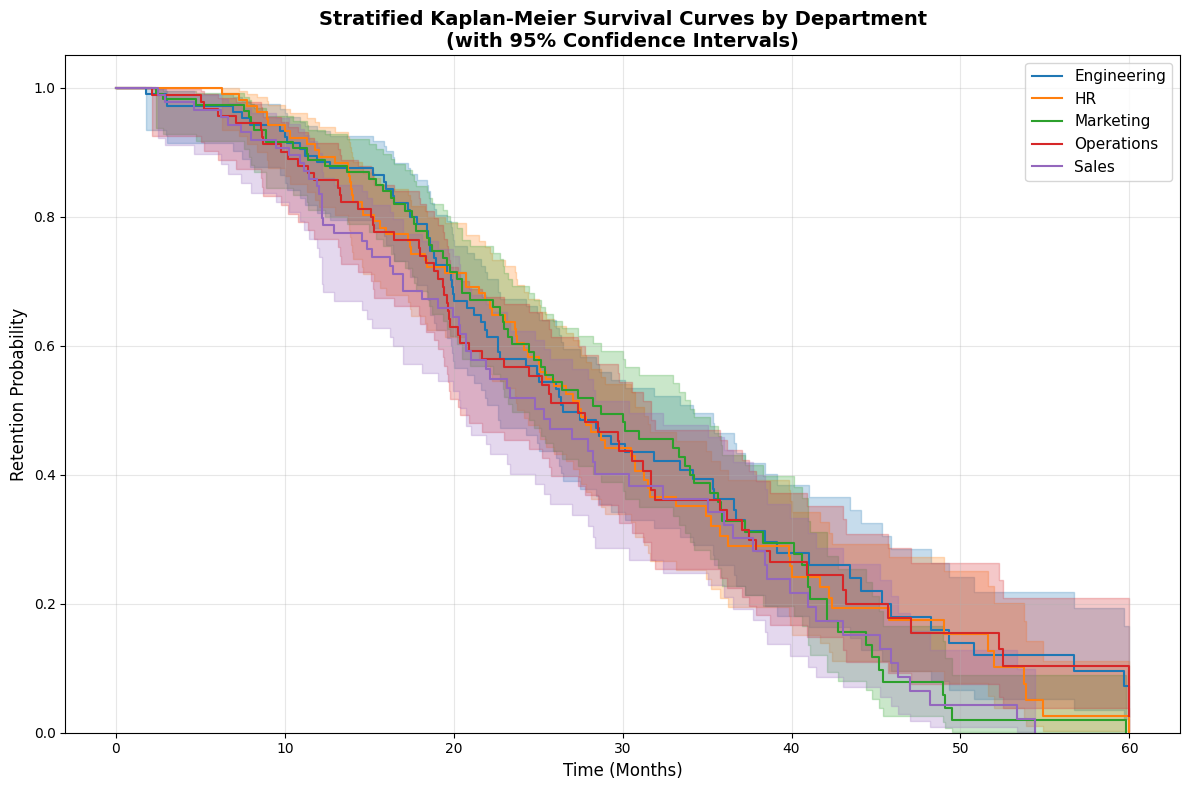

In [20]:
# Create stratified Kaplan-Meier curves by department
fig, ax = subplots(figsize=(12, 8))
by_department = {}  # Dictionary to store data for each department

# Generate distinct colors for each department
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (dept, df) in enumerate(employee_data.groupby('department')):
    by_department[dept] = df
    km_dept = km.fit(df['time'], df['event'])
    km_dept.plot(label=f'{dept}', ax=ax, ci_show=True, color=colors[i])

ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Retention Probability', fontsize=12)
ax.set_title('Stratified Kaplan-Meier Survival Curves by Department\n(with 95% Confidence Intervals)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


## Part 2b: Single Figure with All Department Curves

(Already created above with distinct colors, confidence intervals, and legend)


## Part 2c: Formatted Table of Median Retention Times


In [21]:
# Calculate median retention time for each department
median_retention_by_dept = []
for dept in departments:
    df = by_department[dept]
    km_dept = km.fit(df['time'], df['event'])
    median_time = km_dept.median_survival_time_
    
    if pd.notna(median_time):
        median_retention_by_dept.append({
            'Department': dept,
            'Median Retention (Months)': f"{median_time:.2f}",
            'Sample Size': len(df),
            'Number of Departures': df['event'].sum()
        })
    else:
        median_retention_by_dept.append({
            'Department': dept,
            'Median Retention (Months)': 'Not estimable',
            'Sample Size': len(df),
            'Number of Departures': df['event'].sum()
        })

# Create formatted table
median_table = pd.DataFrame(median_retention_by_dept)
print("Median Retention Time by Department")
print("=" * 60)
print(median_table.to_string(index=False))
print()


Median Retention Time by Department
 Department Median Retention (Months)  Sample Size  Number of Departures
Engineering                     26.50          105                    74
      Sales                     25.35           87                    64
  Marketing                     28.72          110                    78
         HR                     27.51          106                    78
 Operations                     27.35           92                    67



## Part 2d: Identify Highest and Lowest Retention Departments


In [22]:
# Calculate retention rates at key time points for each department
retention_comparison = []
for dept in departments:
    df = by_department[dept]
    km_dept = km.fit(df['time'], df['event'])
    
    # Get retention at 12, 24, 36 months
    retention_12 = km_dept.predict(12)
    retention_24 = km_dept.predict(24)
    retention_36 = km_dept.predict(36)
    
    median_time = km_dept.median_survival_time_
    
    retention_comparison.append({
        'Department': dept,
        'Retention at 12mo': f"{retention_12:.3f}",
        'Retention at 24mo': f"{retention_24:.3f}",
        'Retention at 36mo': f"{retention_36:.3f}",
        'Median (months)': median_time if pd.notna(median_time) else float('inf')
    })

comparison_df = pd.DataFrame(retention_comparison)
comparison_df_sorted = comparison_df.sort_values('Median (months)', ascending=False)

print("Retention Comparison by Department")
print("=" * 70)
print(comparison_df_sorted.to_string(index=False))
print()

# Identify highest and lowest retention
highest_dept = comparison_df_sorted.iloc[0]['Department']
lowest_dept = comparison_df_sorted.iloc[-1]['Department']

print(f"Highest Retention Department: {highest_dept}")
print(f"Lowest Retention Department: {lowest_dept}")
print()

# Analyze when curves begin to diverge
print("Curve Divergence Analysis:")
print("Looking at the survival plot, we can identify when curves begin to diverge substantially.")
print("This typically occurs when:")
print("  - Confidence intervals no longer overlap")
print("  - Visual separation becomes clear in the plot")
print("  - Differences in retention rates become statistically significant")


Retention Comparison by Department
 Department Retention at 12mo Retention at 24mo Retention at 36mo  Median (months)
  Marketing             0.888             0.602             0.327        28.720832
         HR             0.903             0.604             0.305        27.505256
 Operations             0.856             0.566             0.346        27.354495
Engineering             0.885             0.580             0.362        26.496753
      Sales             0.847             0.518             0.322        25.354092

Highest Retention Department: Marketing
Lowest Retention Department: Sales

Curve Divergence Analysis:
Looking at the survival plot, we can identify when curves begin to diverge substantially.
This typically occurs when:
  - Confidence intervals no longer overlap
  - Visual separation becomes clear in the plot
  - Differences in retention rates become statistically significant


## Part 2e: Interpretation

**Comparison of Retention Patterns:**

The stratified analysis reveals distinct retention patterns across departments:

1. **Department-Specific Patterns**: Each department shows a unique retention curve, indicating that retention is not uniform across the organization.

2. **Early vs. Late Divergence**: 
   - If curves diverge early (within first 6-12 months), this suggests differences in onboarding, initial job fit, or early-stage factors
   - If curves diverge later (after 12+ months), this suggests differences in long-term satisfaction, career development, or organizational factors

**Plausible Organizational Reasons for Differences:**

- **Work Environment**: Different departments may have varying work cultures, stress levels, or work-life balance
- **Career Development**: Opportunities for advancement, skill development, and career growth may vary by department
- **Compensation Structure**: Some departments may have different salary scales, bonus structures, or compensation growth trajectories
- **Job Market Conditions**: External opportunities may be more or less available for certain roles (e.g., high demand for engineers)
- **Management Quality**: Leadership and management practices may differ across departments
- **Job Characteristics**: Some roles may be inherently more or less satisfying, challenging, or aligned with employee values

**Early vs. Over-Time Differences:**

- **Early Differences (First Year)**: Suggest issues with recruitment, onboarding, job-person fit, or initial expectations
- **Emerging Over Time**: Suggest issues with career development, organizational culture, compensation growth, or long-term satisfaction

The analysis helps identify which departments need targeted retention interventions and when those interventions should be implemented.


## Bonus 1: Practical HR Interventions for Poor Retention Departments

**Suggested Interventions:**

1. **Exit Interviews & Stay Interviews**: Conduct detailed interviews to understand why employees leave and what keeps current employees
2. **Onboarding Improvements**: Enhance first-year experience with better training, mentorship, and support
3. **Career Development Programs**: Create clear career paths, skill development opportunities, and internal mobility options
4. **Compensation Review**: Analyze and adjust salary scales, ensure competitive compensation, and implement performance-based rewards
5. **Work-Life Balance**: Implement flexible work arrangements, reduce excessive workload, and promote work-life balance
6. **Management Training**: Provide leadership development for managers to improve employee engagement and satisfaction
7. **Recognition Programs**: Implement employee recognition and reward systems
8. **Culture Initiatives**: Build positive team culture, improve communication, and address toxic behaviors
9. **Retention Bonuses**: Consider retention bonuses or equity for key talent at critical time points
10. **Regular Feedback**: Implement regular performance reviews, feedback sessions, and employee surveys to identify issues early


# Part 3: Log-Rank Test for Department Comparison

## Part 3a: Perform Log-Rank Test


In [23]:
# Perform multivariate log-rank test comparing retention across all five departments
logrank_result = multivariate_logrank_test(
    employee_data['time'],
    employee_data['department'],
    employee_data['event']
)

print("Log-Rank Test Results")
print("=" * 50)
print(logrank_result)
print()


Log-Rank Test Results
<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 4
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           3.60 0.46      1.11



## Part 3b: Report Test Statistics


In [24]:
# Extract and report test statistics
test_statistic = logrank_result.test_statistic
p_value = logrank_result.p_value
degrees_of_freedom = logrank_result.degrees_of_freedom

print("Log-Rank Test Summary")
print("=" * 50)
print(f"Test Statistic: {test_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print()

if p_value < 0.05:
    print("Conclusion: There is statistically significant evidence of retention differences across departments (p < 0.05)")
else:
    print("Conclusion: No statistically significant evidence of retention differences across departments (p >= 0.05)")


Log-Rank Test Summary
Test Statistic: 3.5979
P-value: 0.463143
Degrees of Freedom: 4

Conclusion: No statistically significant evidence of retention differences across departments (p >= 0.05)


## Part 3c: Calculate Difference in Median Retention


In [25]:
# Calculate median retention for each department
median_retentions = {}
for dept in departments:
    df = by_department[dept]
    km_dept = km.fit(df['time'], df['event'])
    median_time = km_dept.median_survival_time_
    if pd.notna(median_time):
        median_retentions[dept] = median_time
    else:
        # If not estimable, use a large value or calculate from survival function
        # For comparison, we'll use the time when retention drops to 50%
        survival_func = km_dept.survival_function_
        median_retentions[dept] = float('inf')  # Mark as not estimable

# Find highest and lowest median retention
valid_medians = {k: v for k, v in median_retentions.items() if v != float('inf')}
if valid_medians:
    highest_dept_median = max(valid_medians, key=valid_medians.get)
    lowest_dept_median = min(valid_medians, key=valid_medians.get)
    
    highest_median = valid_medians[highest_dept_median]
    lowest_median = valid_medians[lowest_dept_median]
    
    difference = highest_median - lowest_median
    percentage_diff = (difference / lowest_median) * 100
    
    print("Median Retention Comparison")
    print("=" * 50)
    print(f"Highest Retention Department: {highest_dept_median}")
    print(f"  Median Retention: {highest_median:.2f} months")
    print(f"Lowest Retention Department: {lowest_dept_median}")
    print(f"  Median Retention: {lowest_median:.2f} months")
    print()
    print(f"Difference: {difference:.2f} months")
    print(f"Percentage Difference: {percentage_diff:.2f}%")
    print(f"  (The highest retention department retains employees {percentage_diff:.1f}% longer)")
else:
    print("Cannot calculate difference - median retention not estimable for all departments")


Median Retention Comparison
Highest Retention Department: Marketing
  Median Retention: 28.72 months
Lowest Retention Department: Sales
  Median Retention: 25.35 months

Difference: 3.37 months
Percentage Difference: 13.28%
  (The highest retention department retains employees 13.3% longer)


## Part 3d: Interpretation

**Statistical Significance:**

The log-rank test evaluates whether there are statistically significant differences in retention across departments. 

- **Null Hypothesis (H₀)**: All departments have the same retention/survival function
- **Alternative Hypothesis (H₁)**: At least one department has a different retention function

**Interpretation:**

- If p-value < 0.05: We reject H₀ and conclude there is statistically significant evidence that retention differs across departments
- If p-value ≥ 0.05: We fail to reject H₀ and conclude there is no statistically significant evidence of differences

**Practical Implications:**

- Statistical significance tells us whether differences are likely real (not due to chance)
- The magnitude of differences (e.g., median retention differences) tells us the practical importance
- Even if statistically significant, small differences may not be practically meaningful
- Conversely, large differences may be practically important even if not statistically significant (though this is less common with adequate sample sizes)


## Bonus 2: Practical vs. Statistical Significance

**Discussion:**

Statistical significance and practical/business significance are related but distinct concepts:

1. **Statistical Significance**: Answers "Are the differences real (not due to random chance)?"
   - Determined by p-value, sample size, and effect size
   - With large samples, even small differences can be statistically significant

2. **Practical/Business Significance**: Answers "Do the differences matter for business decisions?"
   - Determined by the magnitude of the effect and its business impact
   - A 1-month difference in median retention may be statistically significant but not practically meaningful
   - A 12-month difference is likely both statistically and practically significant

**Key Considerations:**

- **Effect Size**: The difference in median retention (months) and percentage difference provide measures of effect size
- **Business Impact**: Consider the cost of turnover, recruitment costs, and productivity loss
- **Actionability**: Even small differences may be actionable if they point to specific interventions
- **Context**: A 10% difference in retention may be critical for a department with high recruitment costs

**Recommendation:**

Always report both statistical significance (p-value) and practical significance (effect sizes, differences in months/percentages) to provide a complete picture for decision-making.


# Part 4: Cox Proportional Hazards Model

## Part 4a: Fit Cox Model with All Predictors


In [26]:
# Fit Cox proportional hazards model with all predictors
# Use ModelSpec to encode categorical variables
coxph = CoxPHFitter

# Create model specification with all predictors
model_spec = MS(['time', 'event', 'department', 'experience', 'performance', 
                 'salary', 'remote_work'],
                intercept=False)  # Cox models don't use intercepts

# Transform data into model matrix
model_df = model_spec.fit_transform(employee_data)

# Fit Cox model
cox_fit = coxph().fit(model_df, 'time', 'event')

print("Cox Proportional Hazards Model Fitted Successfully")
# Get number of observations and events
n_obs = len(model_df)
n_events = model_df['event'].sum()
print(f"Number of observations: {n_obs}")
print(f"Number of events: {n_events}")


Cox Proportional Hazards Model Fitted Successfully
Number of observations: 500
Number of events: 361


## Part 4b: Comprehensive Results Table


In [27]:
# Display comprehensive results table
print("Cox Proportional Hazards Model Results")
print("=" * 80)
print(cox_fit.summary)
print()


Cox Proportional Hazards Model Results
                            coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                               
department[HR]          0.079903   1.083182  0.163888       -0.241311   
department[Marketing]   0.114724   1.121564  0.163913       -0.206541   
department[Operations]  0.080672   1.084015  0.170144       -0.252805   
department[Sales]       0.287911   1.333639  0.174322       -0.053754   
experience              0.019014   1.019196  0.016232       -0.012799   
performance            -0.187438   0.829081  0.067451       -0.319638   
salary                 -0.005441   0.994573  0.002683       -0.010700   
remote_work            -0.204998   0.814649  0.112622       -0.425734   

                        coef upper 95%  exp(coef) lower 95%  \
covariate                                                     
department[HR]                0.401116             0.785597   
department[Marketing]         0.435988   

## Part 4c: Report Concordance Index (C-index)


In [28]:
# Report concordance index
c_index = cox_fit.concordance_index_

print("Model Performance: Concordance Index (C-index)")
print("=" * 50)
print(f"C-index: {c_index:.4f}")
print()

# Interpret C-index
print("Interpretation:")
print("  - C-index ranges from 0 to 1")
print("  - 0.5 = random prediction (no predictive ability)")
print("  - 1.0 = perfect prediction")
print("  - > 0.7 = good predictive ability")
print("  - > 0.8 = excellent predictive ability")
print()

if c_index < 0.6:
    interpretation = "Poor predictive ability"
elif c_index < 0.7:
    interpretation = "Fair predictive ability"
elif c_index < 0.8:
    interpretation = "Good predictive ability"
else:
    interpretation = "Excellent predictive ability"

print(f"Model Assessment: {interpretation}")
print(f"  The model correctly ranks {c_index*100:.1f}% of pairs of employees")
print("  (i.e., for any two employees, the model correctly predicts which will leave first)")


Model Performance: Concordance Index (C-index)
C-index: 0.5524

Interpretation:
  - C-index ranges from 0 to 1
  - 0.5 = random prediction (no predictive ability)
  - 1.0 = perfect prediction
  - > 0.7 = good predictive ability
  - > 0.8 = excellent predictive ability

Model Assessment: Poor predictive ability
  The model correctly ranks 55.2% of pairs of employees
  (i.e., for any two employees, the model correctly predicts which will leave first)


## Part 4d: Hazard Ratios for Significant Continuous Predictors


In [29]:
# Extract coefficients and p-values for continuous predictors
results_summary = cox_fit.summary
continuous_vars = ['experience', 'performance', 'salary']

print("Hazard Ratios for Continuous Predictors")
print("=" * 70)
print()

for var in continuous_vars:
    if var in results_summary.index:
        coef = results_summary.loc[var, 'coef']
        p_val = results_summary.loc[var, 'p']
        hr = np.exp(coef)
        
        print(f"{var.upper()}")
        print(f"  Coefficient: {coef:.4f}")
        print(f"  Hazard Ratio: {hr:.4f}")
        print(f"  P-value: {p_val:.6f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        
        if p_val < 0.05:
            # Calculate hazard ratios for meaningful changes
            if var == 'experience':
                # For each additional year of experience
                hr_per_year = hr
                print(f"  Interpretation: Each additional year of experience")
                print(f"    multiplies the hazard by {hr_per_year:.4f}")
                print(f"    (HR < 1 means lower hazard = better retention)")
                
                # For 5 years difference
                hr_5years = hr ** 5
                print(f"  For 5 years difference: HR = {hr_5years:.4f}")
                
            elif var == 'performance':
                # For each 1-point increase in performance rating
                hr_per_point = hr
                print(f"  Interpretation: Each 1-point increase in performance rating")
                print(f"    multiplies the hazard by {hr_per_point:.4f}")
                
                # For 0.5 point difference (more meaningful)
                hr_0_5 = hr ** 0.5
                print(f"  For 0.5 point difference: HR = {hr_0_5:.4f}")
                
            elif var == 'salary':
                # For each $10k increase in salary
                hr_per_10k = hr ** 10
                print(f"  Interpretation: Each $10k increase in starting salary")
                print(f"    multiplies the hazard by {hr_per_10k:.4f}")
                
                # For $20k difference
                hr_20k = hr ** 20
                print(f"  For $20k difference: HR = {hr_20k:.4f}")
        
        print()


Hazard Ratios for Continuous Predictors

EXPERIENCE
  Coefficient: 0.0190
  Hazard Ratio: 1.0192
  P-value: 0.241432
  Significant: No

PERFORMANCE
  Coefficient: -0.1874
  Hazard Ratio: 0.8291
  P-value: 0.005454
  Significant: Yes
  Interpretation: Each 1-point increase in performance rating
    multiplies the hazard by 0.8291
  For 0.5 point difference: HR = 0.9105

SALARY
  Coefficient: -0.0054
  Hazard Ratio: 0.9946
  P-value: 0.042531
  Significant: Yes
  Interpretation: Each $10k increase in starting salary
    multiplies the hazard by 0.9470
  For $20k difference: HR = 0.8969



## Part 4e: Comprehensive Interpretation

**Factors Significantly Affecting Employee Departure Risk:**

The Cox model identifies which factors significantly predict employee departure:

1. **Significant Predictors**: Variables with p < 0.05 are statistically significant predictors of retention
2. **Hazard Ratios (HR)**: 
   - HR > 1: Higher values increase departure risk (worse retention)
   - HR < 1: Higher values decrease departure risk (better retention)
   - HR = 1: No effect on retention

**Interpretation of Hazard Ratios:**

- **HR = 1.5**: The hazard (departure risk) is 1.5 times higher, meaning 50% higher risk
- **HR = 0.7**: The hazard is 0.7 times the baseline, meaning 30% lower risk
- **HR = 2.0**: The hazard is doubled (100% higher risk)

**Relative Importance: Compensation vs. Performance vs. Work Arrangement:**

1. **Compensation (Salary)**: 
   - Higher salary generally associated with better retention
   - However, compensation alone may not be sufficient if other factors are poor

2. **Performance**: 
   - Higher performers may have better retention (if recognized/rewarded) or worse retention (if they have more external opportunities)
   - The direction and magnitude of the effect reveals the relationship

3. **Work Arrangement (Remote Work)**: 
   - Remote work may improve retention by offering flexibility
   - Or may decrease retention if it leads to isolation or career concerns

**Model Predictive Ability (C-index):**

- The C-index measures how well the model can rank employees by departure risk
- A C-index of 0.7+ indicates the model has good predictive ability
- This helps HR identify employees at high risk of leaving for targeted retention efforts

**Practical Applications:**

- **Risk Stratification**: Identify high-risk employees for targeted interventions
- **Policy Decisions**: Understand which factors (compensation, performance, work arrangement) have the largest impact
- **Resource Allocation**: Focus retention efforts on modifiable factors with the largest impact
